In [1]:
# Importing Python Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load Dataset

sales_daily = pd.read_csv("D:\\Alldataset\Zidio InternShip\\sales_daily.csv")
inventory_snapshots = pd.read_csv("D:\\Alldataset\Zidio InternShip\\inventory_snapshots.csv")
calendar = pd.read_csv("D:\\Alldataset\Zidio InternShip\\calendar.csv")
sku_master = pd.read_csv("D:\\Alldataset\Zidio InternShip\\sku_master.csv")


# cheacking first two raw & last two raw sales_daily


In [3]:
sales_daily.head(2) # Display First 2 Rows


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0


In [4]:
sales_daily.tail(2) # Display Last 2 Rows


,Date,SKU,Units_Sold,Revenue,Price,Promotion
36548,2025-12-31,SKU049,16,83573.92,5223.37,0
36549,2025-12-31,SKU050,9,7944.48,882.72,0


# cheacking first two raw & last two raw inventory_snapshots


In [5]:
inventory_snapshots.head(2) # Display First 2 Rows


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40


In [6]:
inventory_snapshots.tail(2) # Display Last 2 Rows


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
4798,2025-12-01,SKU199,347,306,14,83,292,1246941.03
4799,2025-12-01,SKU200,96,65,9,18,68,292328.64


# cheacking first two raw & last two raw calendar


In [7]:
calendar.head(2) # Display First 2 Raws


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,None,0,None
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,None,0,None


In [8]:
calendar.tail(2) # Display Last 2 Raws


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
729,2025-12-30,2025,12,Q4,1,Tuesday,0,Winter,None,0,None
730,2025-12-31,2025,12,Q4,1,Wednesday,0,Winter,None,0,None


# cheacking first two raw & last two raw sku_master


In [9]:
sku_master.head(2) # Display First 2 Raws


,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,SKU001,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.6
1,SKU002,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.4


In [10]:
sku_master.tail(2) # Display Last 2 Raws


,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
48,SKU049,Product 049,Lighting,Organizer,2024-01-16,2063.03,5223.37,3160.34
49,SKU050,Product 050,Storage,Sofa,2024-05-06,701.85,882.72,180.87


# Cheacking data shape


In [11]:
sales_daily.shape


(36550, 6)

In [12]:
inventory_snapshots.shape


(4800, 8)

In [13]:
calendar.shape


(731, 11)

In [14]:
sku_master.shape


(50, 8)

# Cheacking Null Value


In [15]:
sales_daily.isnull().sum()


Date          0
SKU           0
Units_Sold    0
Revenue       0
Price         0
Promotion     0
dtype: int64

In [16]:
inventory_snapshots.isnull().sum()


Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64

In [17]:
inventory_snapshots.isnull().sum()


Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64

In [18]:
sku_master.isnull().sum()


SKU                      0
Product_Name             0
Category                 0
Subcategory              0
Launch_Date              0
Cost_Price               0
Selling_Price            0
Gross_Margin_Per_Unit    0
dtype: int64

In [19]:
# Cheacking Null Value in calendar (isse pehle miss ho gaya tha)

calendar.isnull().sum()


date               0
year               0
month              0
quarter            0
week               0
day_of_week        0
is_weekend         0
season             0
holiday            0
is_holiday         0
promotion_event    0
dtype: int64

# Cheacking Duplicate Rows


In [20]:
print("Duplicates in sales_daily:", sales_daily.duplicated().sum())
print("Duplicates in inventory_snapshots:", inventory_snapshots.duplicated().sum())
print("Duplicates in calendar:", calendar.duplicated().sum())
print("Duplicates in sku_master:", sku_master.duplicated().sum())


Duplicates in sales_daily: 0
Duplicates in inventory_snapshots: 0
Duplicates in calendar: 0
Duplicates in sku_master: 0


# Cheacking SKU Overlap Between Files


In [21]:
print("Unique SKUs in sales_daily:", sales_daily['SKU'].nunique())
print("Unique SKUs in sku_master:", sku_master['SKU'].nunique())
print("Unique SKUs in inventory_snapshots:", inventory_snapshots['SKU'].nunique())

extra_skus = set(inventory_snapshots['SKU'].unique()) - set(sku_master['SKU'].unique())
print("SKUs in inventory but NOT in sku_master:", len(extra_skus))


Unique SKUs in sales_daily: 50
Unique SKUs in sku_master: 50
Unique SKUs in inventory_snapshots: 200
SKUs in inventory but NOT in sku_master: 150


In [22]:
# Note: inventory_snapshots mein 200 SKUs hain lekin sales_daily aur sku_master mein sirf 50 hain.
# Isliye hum sirf un 50 common SKUs par kaam karenge jinke paas sales history AND product info dono hai.


# Converting Date Columns to Datetime Format


In [23]:
sales_daily['Date'] = pd.to_datetime(sales_daily['Date'])
inventory_snapshots['Snapshot_Date'] = pd.to_datetime(inventory_snapshots['Snapshot_Date'])
calendar['date'] = pd.to_datetime(calendar['date'])
sku_master['Launch_Date'] = pd.to_datetime(sku_master['Launch_Date'])


# Filtering Common SKUs


In [24]:
common_skus = sorted(set(sales_daily['SKU']) & set(sku_master['SKU']))
print("Common SKUs:", len(common_skus))

sales_daily = sales_daily[sales_daily['SKU'].isin(common_skus)].copy()
inventory_snapshots = inventory_snapshots[inventory_snapshots['SKU'].isin(common_skus)].copy()


Common SKUs: 50


# Merging All Datasets Into One Table


In [25]:
df = sales_daily.merge(calendar, left_on='Date', right_on='date', how='left')
df = df.merge(sku_master, on='SKU', how='left')
df = df.sort_values(['SKU', 'Date']).reset_index(drop=True)

print(df.shape)
df.head()


(36550, 24)


,Date,SKU,Units_Sold,Revenue,Price,Promotion,date,year,month,quarter,...,holiday,is_holiday,promotion_event,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,2024-01-01,SKU001,5,18320.25,3664.05,0,2024-01-01,2024,1,Q1,...,None,0,None,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.6
1,2024-01-02,SKU001,13,47632.65,3664.05,0,2024-01-02,2024,1,Q1,...,None,0,None,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.6
2,2024-01-03,SKU001,12,43968.60,3664.05,0,2024-01-03,2024,1,Q1,...,None,0,None,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.6
3,2024-01-04,SKU001,23,84273.15,3664.05,0,2024-01-04,2024,1,Q1,...,None,0,None,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.6
4,2024-01-05,SKU001,16,58624.80,3664.05,0,2024-01-05,2024,1,Q1,...,None,0,None,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.6


# EDA: Total Daily Sales Trend


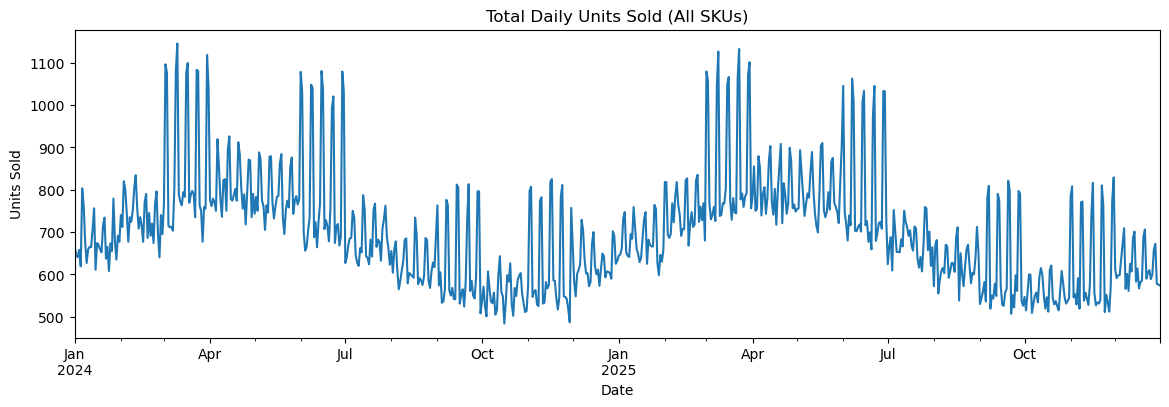

In [26]:
daily_total = df.groupby('Date')['Units_Sold'].sum()

plt.figure(figsize=(14, 4))
daily_total.plot()
plt.title('Total Daily Units Sold (All SKUs)')
plt.ylabel('Units Sold')
plt.show()


# EDA: Category-Wise Sales


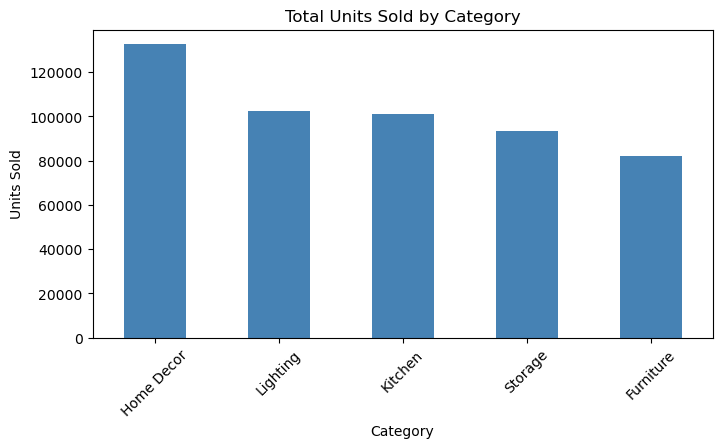

In [27]:
category_sales = df.groupby('Category')['Units_Sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
category_sales.plot(kind='bar', color='steelblue')
plt.title('Total Units Sold by Category')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.show()


# EDA: Weekend vs Weekday Average Demand


In [28]:
df.groupby('is_weekend')['Units_Sold'].mean()


is_weekend
0    13.077744
1    16.329519
Name: Units_Sold, dtype: float64

# Feature Engineering


In [29]:
# Forecasting model ke liye lag features aur rolling averages banayenge


In [30]:
df['dow'] = df['Date'].dt.dayofweek
df['month_num'] = df['Date'].dt.month

df['lag_7'] = df.groupby('SKU')['Units_Sold'].shift(7)
df['rolling_mean_7'] = df.groupby('SKU')['Units_Sold'].transform(lambda x: x.shift(1).rolling(7).mean())
df['rolling_mean_28'] = df.groupby('SKU')['Units_Sold'].transform(lambda x: x.shift(1).rolling(28).mean())

# SKU ko numeric code mein convert karo (model ke liye zaroori)
df['SKU_code'] = df['SKU'].astype('category').cat.codes


In [31]:
# Shuru ke rows drop karo jinme lag/rolling features NaN hain
df_model = df.dropna(subset=['lag_7', 'rolling_mean_7', 'rolling_mean_28']).copy()
print("Final modeling data shape:", df_model.shape)


Final modeling data shape: (35150, 30)


# Train-Test Split


In [32]:
# Time series hai isliye time ke hisaab se split karenge (random split nahi)


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

features = ['dow', 'month_num', 'is_weekend', 'is_holiday', 'Price',
            'Promotion', 'lag_7', 'rolling_mean_7', 'rolling_mean_28', 'SKU_code']
target = 'Units_Sold'

split_date = df_model['Date'].quantile(0.8)
train = df_model[df_model['Date'] < split_date]
test = df_model[df_model['Date'] >= split_date]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Train size: {len(train)}, Test size: {len(test)}")
print(f"Split date: {split_date.date()}")


Train size: 28100, Test size: 7050
Split date: 2025-08-13


# Model Training (Random Forest)


In [34]:
model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test.clip(lower=1), np.clip(predictions, 1, None))

print(f"MAE  (Mean Absolute Error): {mae:.2f} units")
print(f"MAPE (Mean Absolute % Error): {mape*100:.1f}%")


MAE  (Mean Absolute Error): 2.77 units
MAPE (Mean Absolute % Error): 34.9%


# Feature Importance Dekho


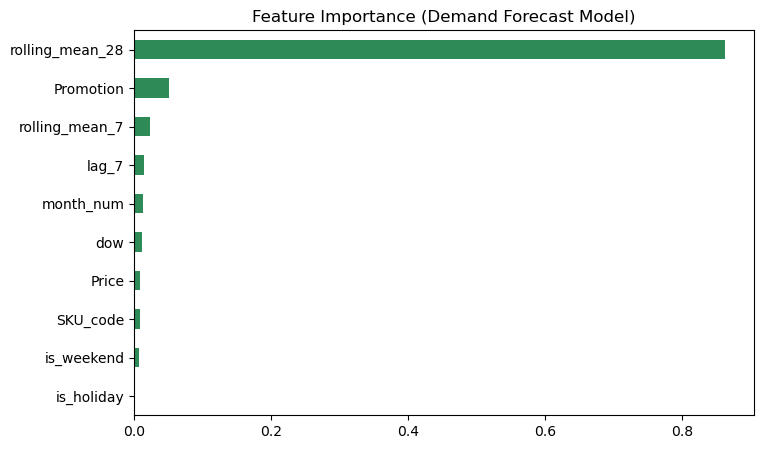

In [35]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='seagreen')
plt.title('Feature Importance (Demand Forecast Model)')
plt.gca().invert_yaxis()
plt.show()


# Ek SKU Ka Actual vs Predicted Graph


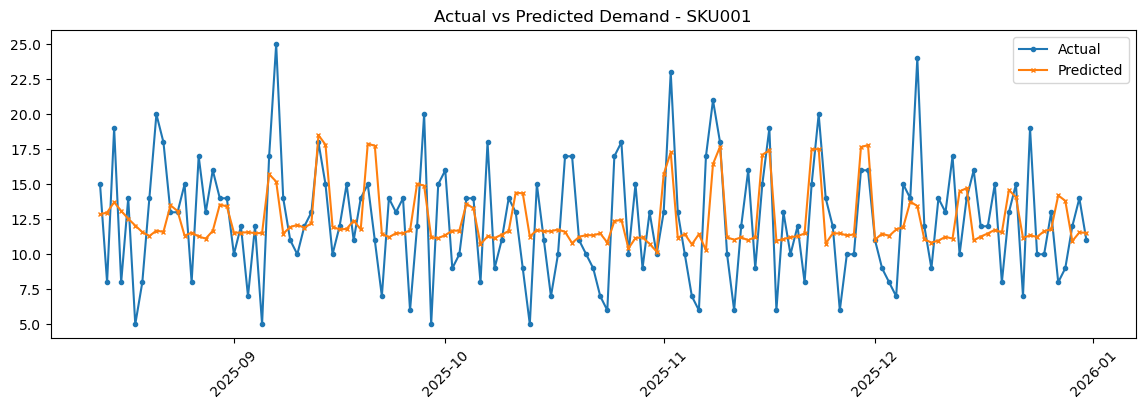

In [36]:
sample_sku = common_skus[0]
sample_test = test[test['SKU'] == sample_sku].copy()
sample_test['Predicted'] = model.predict(sample_test[features])

plt.figure(figsize=(14, 4))
plt.plot(sample_test['Date'], sample_test['Units_Sold'], label='Actual', marker='o', markersize=3)
plt.plot(sample_test['Date'], sample_test['Predicted'], label='Predicted', marker='x', markersize=3)
plt.title(f'Actual vs Predicted Demand - {sample_sku}')
plt.legend()
plt.xticks(rotation=45)
plt.show()


# Stockout / Overstock Risk Detection


In [37]:
# Latest inventory snapshot ko average daily demand ke saath compare karke risk classify karenge


In [38]:
latest_date = inventory_snapshots['Snapshot_Date'].max()
latest_inv = inventory_snapshots[inventory_snapshots['Snapshot_Date'] == latest_date].copy()

avg_daily_demand = df_model.groupby('SKU')['Units_Sold'].mean().rename('avg_daily_demand')
latest_inv = latest_inv.merge(avg_daily_demand, on='SKU', how='left')
latest_inv['days_of_stock'] = latest_inv['Current_Stock'] / latest_inv['avg_daily_demand']


In [39]:
def classify_risk(row):
    if row['days_of_stock'] < row['Lead_Time_Days']:
        return 'Stockout Risk'
    elif row['days_of_stock'] > row['Lead_Time_Days'] * 4:
        return 'Overstock Risk'
    else:
        return 'Healthy'

latest_inv['Risk_Status'] = latest_inv.apply(classify_risk, axis=1)

print(latest_inv['Risk_Status'].value_counts())
latest_inv[['SKU', 'Current_Stock', 'avg_daily_demand', 'days_of_stock',
            'Lead_Time_Days', 'Risk_Status']].sort_values('days_of_stock').head(15)


Healthy           22
Overstock Risk    18
Stockout Risk     10
Name: Risk_Status, dtype: int64


,SKU,Current_Stock,avg_daily_demand,days_of_stock,Lead_Time_Days,Risk_Status
33,SKU034,34,20.186344,1.684307,5,Stockout Risk
11,SKU012,47,26.098151,1.800894,12,Stockout Risk
41,SKU042,90,22.762447,3.953881,6,Stockout Risk
39,SKU040,67,15.620199,4.289318,9,Stockout Risk
9,SKU010,83,17.086771,4.857559,13,Stockout Risk
30,SKU031,93,18.769559,4.954831,13,Stockout Risk
16,SKU017,95,14.258890,6.662510,12,Stockout Risk
8,SKU009,75,10.726885,6.991778,7,Stockout Risk
25,SKU026,160,22.633001,7.069323,5,Healthy
6,SKU007,207,24.770982,8.356552,8,Healthy


# Risk Distribution Graph


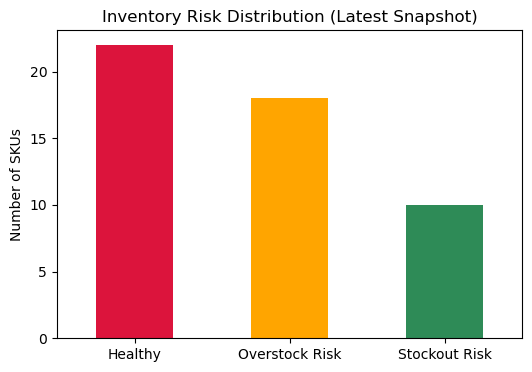

In [40]:
plt.figure(figsize=(6, 4))
latest_inv['Risk_Status'].value_counts().plot(kind='bar', color=['crimson', 'orange', 'seagreen'])
plt.title('Inventory Risk Distribution (Latest Snapshot)')
plt.ylabel('Number of SKUs')
plt.xticks(rotation=0)
plt.show()


# Final Output Save Karo (Dashboard Ke Liye)


In [41]:
output = latest_inv.merge(sku_master[['SKU', 'Product_Name', 'Category']], on='SKU', how='left')
output = output[['SKU', 'Product_Name', 'Category', 'Current_Stock', 'avg_daily_demand',
                  'days_of_stock', 'Lead_Time_Days', 'Reorder_Point', 'Risk_Status']]

output.to_csv('foresight_risk_output.csv', index=False)
print("Saved: foresight_risk_output.csv")
output.head()


Saved: foresight_risk_output.csv


,SKU,Product_Name,Category,Current_Stock,avg_daily_demand,days_of_stock,Lead_Time_Days,Reorder_Point,Risk_Status
0,SKU001,Product 001,Furniture,771,14.374111,53.638100,4,289,Overstock Risk
1,SKU002,Product 002,Home Decor,526,10.169275,51.724437,3,149,Overstock Risk
2,SKU003,Product 003,Kitchen,349,5.790896,60.267011,3,123,Overstock Risk
3,SKU004,Product 004,Lighting,259,4.627312,55.972026,6,196,Overstock Risk
4,SKU005,Product 005,Storage,471,16.729730,28.153473,6,245,Overstock Risk


# Dashboard Ke Liye Extra Files Save Karo


In [42]:
# Sales history save karo (dashboard mein trend charts ke liye)
sales_history = df_model[['Date', 'SKU', 'Product_Name', 'Category', 'Units_Sold']].copy()
sales_history.to_csv('sales_history.csv', index=False)

# Test set ke actual vs predicted results save karo (sabhi SKUs ke liye)
test_results = test[['Date', 'SKU']].copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = predictions
test_results.to_csv('forecast_results.csv', index=False)

print("Saved: sales_history.csv, forecast_results.csv")


Saved: sales_history.csv, forecast_results.csv


# Future Demand Predict Karo


In [43]:
# Abhi tak humne sirf test data (jo pehle se pata tha) par predict kiya tha.
# Ab hum agle 30 dinon ka NAYA demand forecast karenge — jo abhi tak hua hi nahi.


In [44]:
# SKU code mapping banao (future prediction ke liye zaroori)
sku_code_map = df_model.drop_duplicates('SKU').set_index('SKU')['SKU_code'].to_dict()

def forecast_future(sku, n_days=30):
    """Ek SKU ke liye agle n_days ka demand forecast karta hai (recursive method)."""
    hist = df_model[df_model['SKU'] == sku].sort_values('Date').copy()
    last_date = hist['Date'].max()
    last_price = hist['Price'].iloc[-1]
    sku_code = sku_code_map[sku]

    # Pichle 28 din ki actual sales (lag/rolling calculate karne ke liye)
    recent_sales = list(hist['Units_Sold'].values[-28:])

    future_rows = []
    for i in range(1, n_days + 1):
        future_date = last_date + pd.Timedelta(days=i)
        dow = future_date.dayofweek
        month_num = future_date.month
        is_weekend = 1 if dow >= 5 else 0
        is_holiday = 0        # Future holiday pata nahi, isliye 0 maan liya
        promotion = 0         # Future promotion pata nahi, isliye 0 maan liya

        lag_7 = recent_sales[-7]
        rolling_mean_7 = np.mean(recent_sales[-7:])
        rolling_mean_28 = np.mean(recent_sales[-28:])

        row = {
            'dow': dow, 'month_num': month_num, 'is_weekend': is_weekend,
            'is_holiday': is_holiday, 'Price': last_price, 'Promotion': promotion,
            'lag_7': lag_7, 'rolling_mean_7': rolling_mean_7,
            'rolling_mean_28': rolling_mean_28, 'SKU_code': sku_code
        }
        pred = model.predict(pd.DataFrame([row])[features])[0]
        pred = max(0, round(pred))

        future_rows.append({'Date': future_date, 'SKU': sku, 'Predicted_Demand': pred})
        recent_sales.append(pred)   # prediction ko history mein daalo, agle din ke liye

    return pd.DataFrame(future_rows)


# Ek SKU Ka Future Forecast Dekho


        Date     SKU  Predicted_Demand
0 2026-01-01  SKU001                13
1 2026-01-02  SKU001                13
2 2026-01-03  SKU001                15
3 2026-01-04  SKU001                16
4 2026-01-05  SKU001                12
5 2026-01-06  SKU001                12
6 2026-01-07  SKU001                12
7 2026-01-08  SKU001                12
8 2026-01-09  SKU001                12
9 2026-01-10  SKU001                14


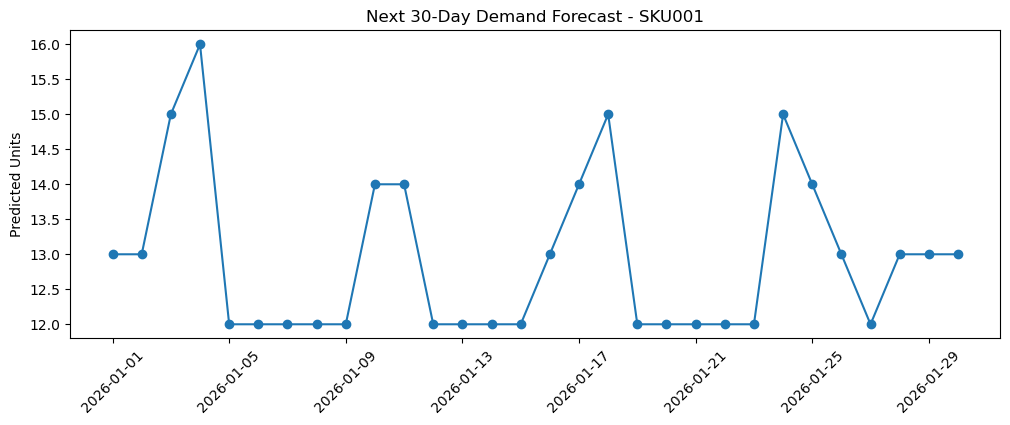

In [45]:
sample_forecast = forecast_future('SKU001', n_days=30)
print(sample_forecast.head(10))

plt.figure(figsize=(12, 4))
plt.plot(sample_forecast['Date'], sample_forecast['Predicted_Demand'], marker='o')
plt.title('Next 30-Day Demand Forecast - SKU001')
plt.ylabel('Predicted Units')
plt.xticks(rotation=45)
plt.show()


# Sab SKUs Ke Liye Future Forecast Banao


In [46]:
all_forecasts = []
for s in common_skus:
    all_forecasts.append(forecast_future(s, n_days=30))

future_forecast_df = pd.concat(all_forecasts, ignore_index=True)
future_forecast_df = future_forecast_df.merge(sku_master[['SKU', 'Product_Name', 'Category']], on='SKU', how='left')

future_forecast_df.to_csv('future_demand_forecast.csv', index=False)
print("Saved: future_demand_forecast.csv")
print(future_forecast_df.shape)
future_forecast_df.head()


Saved: future_demand_forecast.csv
(1500, 5)


,Date,SKU,Predicted_Demand,Product_Name,Category
0,2026-01-01,SKU001,13,Product 001,Furniture
1,2026-01-02,SKU001,13,Product 001,Furniture
2,2026-01-03,SKU001,15,Product 001,Furniture
3,2026-01-04,SKU001,16,Product 001,Furniture
4,2026-01-05,SKU001,12,Product 001,Furniture
